# Data Preprocessing & EDA

Exploratory checks on the collected driving data before preprocessing. Labels are **(steering, throttle)** in Ackermann convention, not left/right differential motor values.

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from openbot import utils

DATA_DIR = "dataset/train_data"
DATASETS = ["my_dataset_1"]

%matplotlib inline


## Load all processed frame/control logs into one table

The on-disk header still calls the columns `left,right` (legacy name from the differential-drive era), but in this fork they hold `(steering, throttle)` values in Ackermann convention — see `openbot/losses.py`, `openbot/metrics.py`, `openbot/data_augmentation.py`.

In [17]:
def load_dataset(data_dir, datasets):
    rows = []
    for dataset in datasets:
        dataset_dir = os.path.join(data_dir, dataset)
        for session in sorted(utils.list_dirs(dataset_dir)):
            session_dir = os.path.join(dataset_dir, session)
            log_path = os.path.join(
                session_dir, "sensor_data", "matched_frame_ctrl_cmd_processed.txt"
            )
            if not os.path.isfile(log_path):
                continue
            for row in utils.read_csv_dict(log_path):
                # The CSV stores an absolute path from wherever it was generated
                # (e.g. /workspace/... inside a training container), so rebuild
                # the path relative to this session's local images/ folder.
                frame_path = os.path.join(session_dir, "images", os.path.basename(row["frame"]))
                rows.append(
                    {
                        "frame": frame_path,
                        "steering": float(row["left"]),
                        "throttle": float(row["right"]),
                        "cmd": int(row["cmd"]),
                        "session": session,
                        "dataset": dataset,
                    }
                )
    if not rows:
        raise FileNotFoundError(f"No processed logs found under {data_dir} for {datasets}")
    return rows


rows = load_dataset(DATA_DIR, DATASETS)
sessions = sorted(set(r["session"] for r in rows))
print(f"Loaded {len(rows)} frames from {len(sessions)} sessions")
rows[:3]


Loaded 2164 frames from 15 sessions


[{'frame': 'dataset/train_data/my_dataset_1/20260828_080939/images/813_crop.jpeg',
  'steering': 0.0,
  'throttle': 49.0,
  'cmd': 0,
  'session': '20260828_080939',
  'dataset': 'my_dataset_1'},
 {'frame': 'dataset/train_data/my_dataset_1/20260828_080939/images/814_crop.jpeg',
  'steering': 0.0,
  'throttle': 78.0,
  'cmd': 0,
  'session': '20260828_080939',
  'dataset': 'my_dataset_1'},
 {'frame': 'dataset/train_data/my_dataset_1/20260828_080939/images/815_crop.jpeg',
  'steering': 0.0,
  'throttle': 153.0,
  'cmd': 0,
  'session': '20260828_080939',
  'dataset': 'my_dataset_1'}]

## 1. Command / indicator class balance

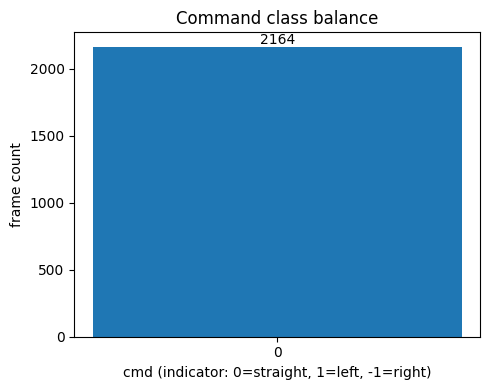

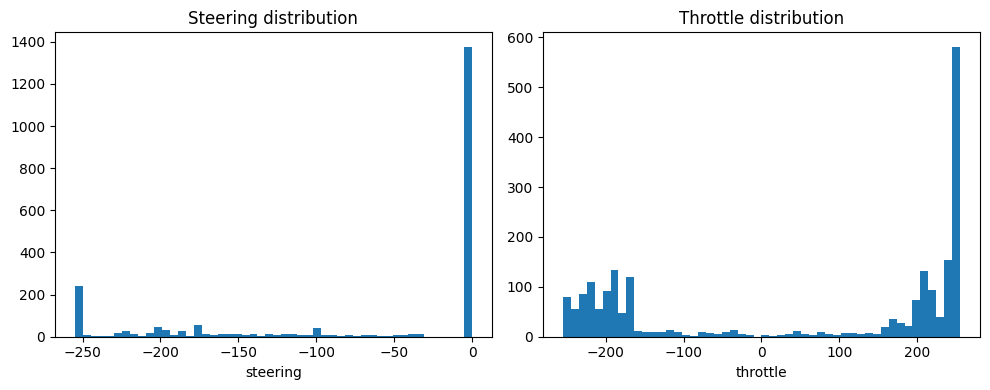

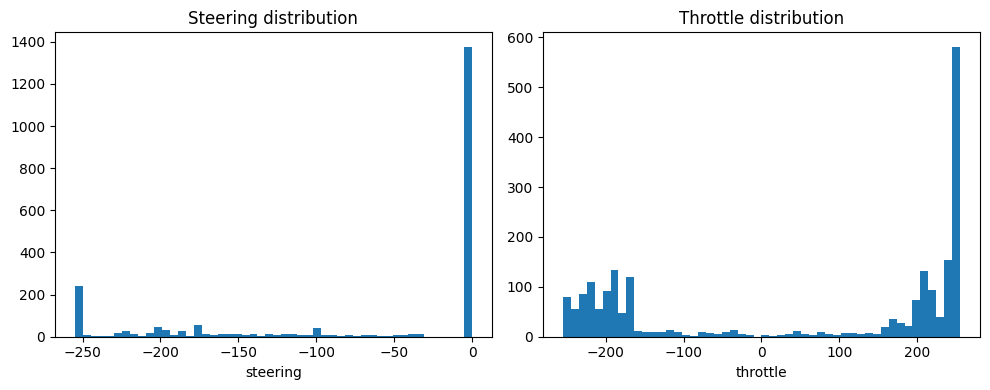

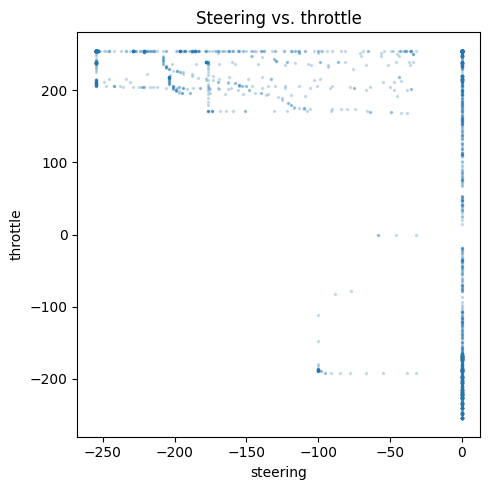

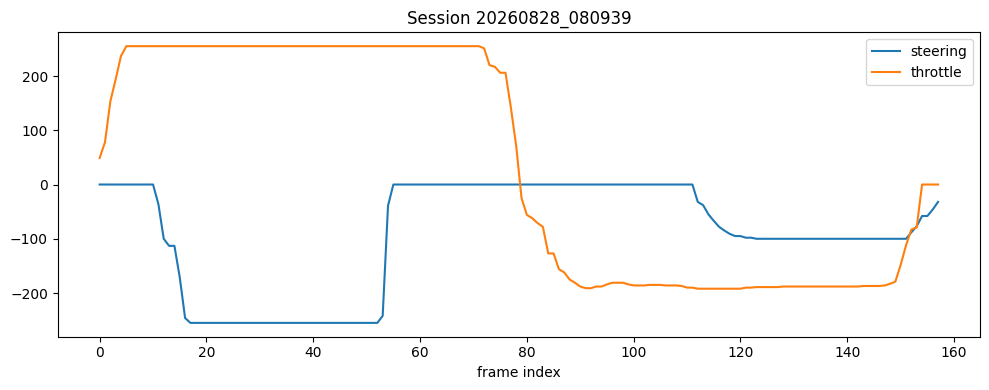

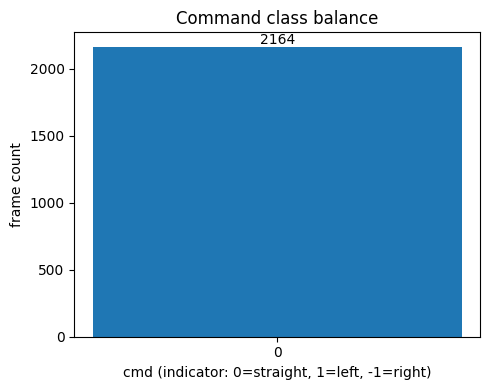

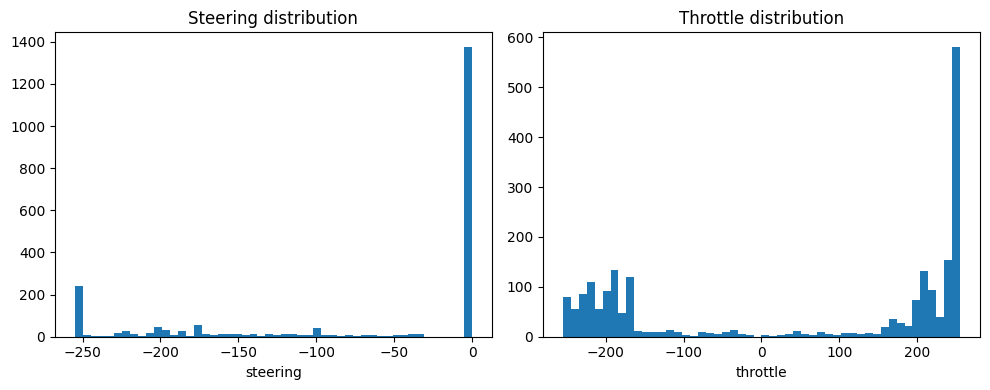

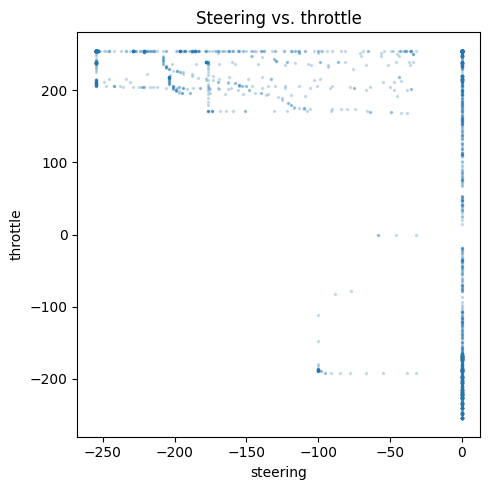

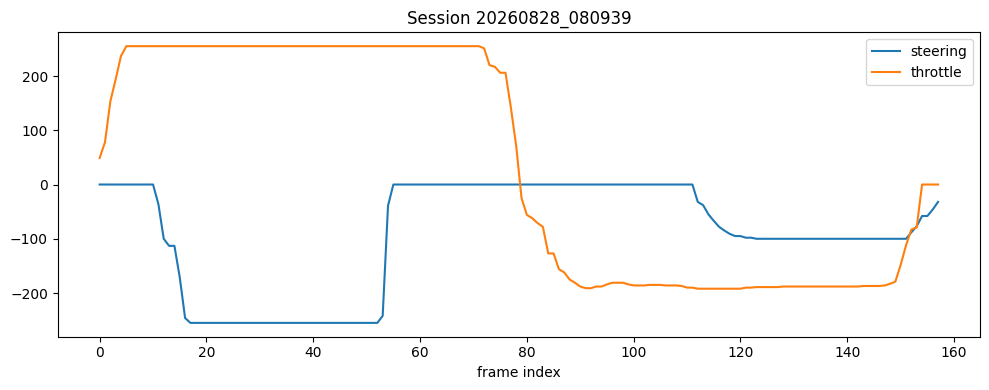

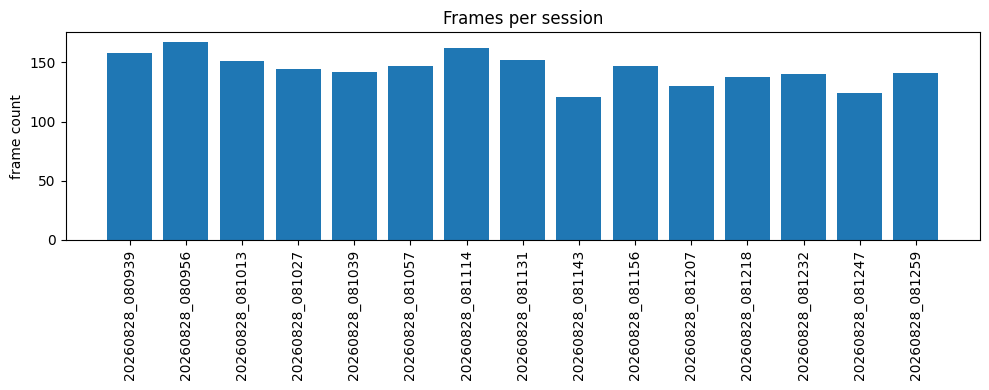

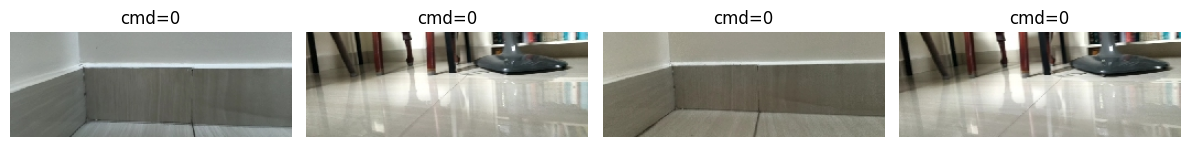

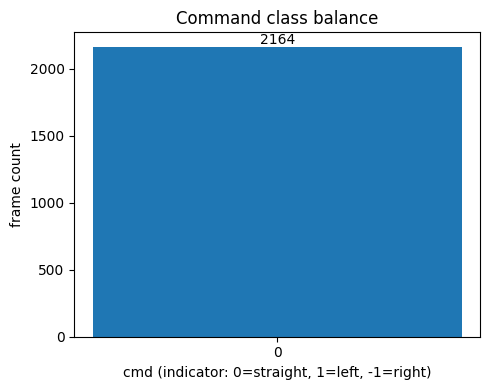

cmd=0: 2164 (100.0%)


In [18]:
cmds = np.array([r["cmd"] for r in rows])
classes, counts = np.unique(cmds, return_counts=True)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([str(c) for c in classes], counts)
ax.set_xlabel("cmd (indicator: 0=straight, 1=left, -1=right)")
ax.set_ylabel("frame count")
ax.set_title("Command class balance")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

for c, n in zip(classes, counts):
    print(f"cmd={c}: {n} ({n / len(rows):.1%})")


## 2. Steering / throttle distributions

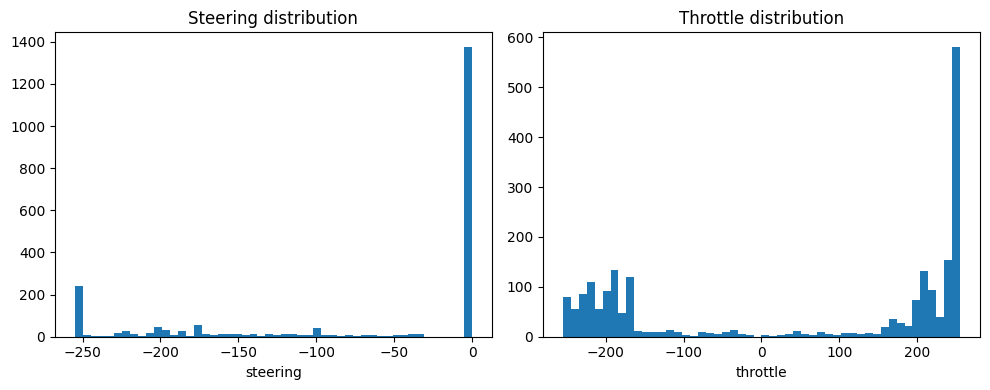

steering: mean=-67.755 std=98.075 min=-255.000 max=0.000
throttle: mean=50.454 std=209.418 min=-255.000 max=255.000


In [19]:
steering = np.array([r["steering"] for r in rows])
throttle = np.array([r["throttle"] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(steering, bins=50)
axes[0].set_title("Steering distribution")
axes[0].set_xlabel("steering")

axes[1].hist(throttle, bins=50)
axes[1].set_title("Throttle distribution")
axes[1].set_xlabel("throttle")

plt.tight_layout()
plt.show()

print(f"steering: mean={steering.mean():.3f} std={steering.std():.3f} min={steering.min():.3f} max={steering.max():.3f}")
print(f"throttle: mean={throttle.mean():.3f} std={throttle.std():.3f} min={throttle.min():.3f} max={throttle.max():.3f}")


## 3. Steering vs. throttle joint distribution

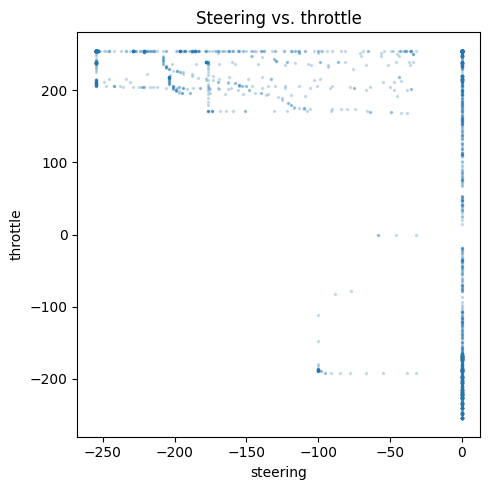

In [20]:
plt.figure(figsize=(5, 5))
plt.scatter(steering, throttle, s=2, alpha=0.2)
plt.xlabel("steering")
plt.ylabel("throttle")
plt.title("Steering vs. throttle")
plt.tight_layout()
plt.show()


## 4. Steering/throttle over time for one session

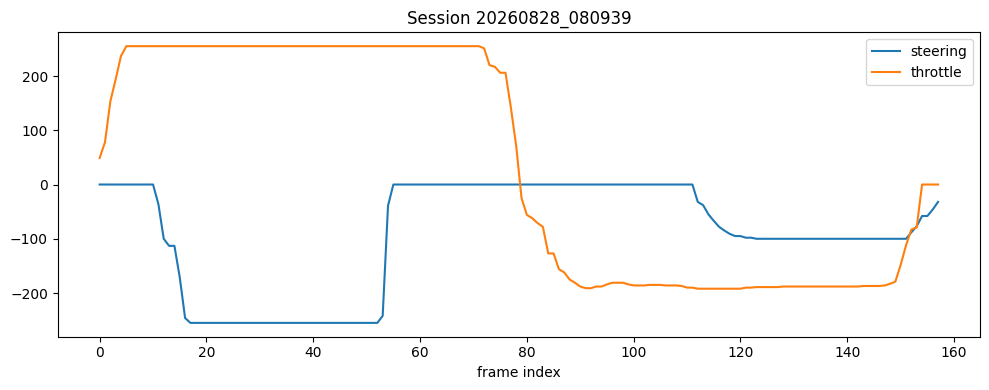

In [21]:
sample_session = sessions[0]
session_rows = [r for r in rows if r["session"] == sample_session]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([r["steering"] for r in session_rows], label="steering")
ax.plot([r["throttle"] for r in session_rows], label="throttle")
ax.set_xlabel("frame index")
ax.set_title(f"Session {sample_session}")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Frame counts per session

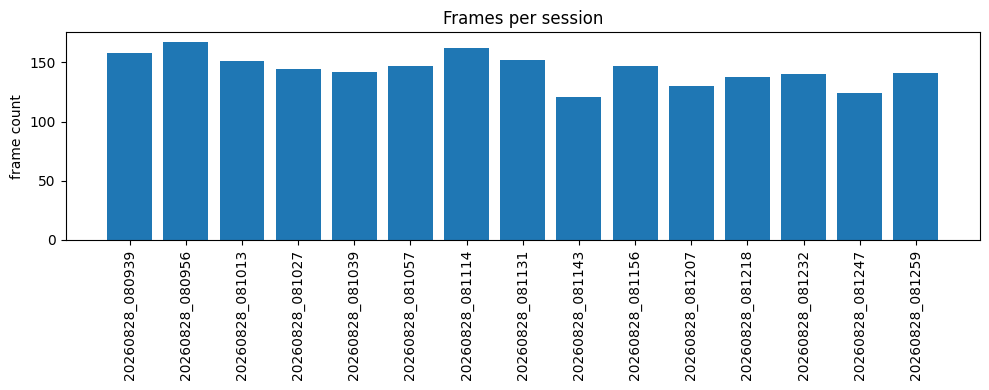

{'20260828_080939': 158,
 '20260828_080956': 167,
 '20260828_081013': 151,
 '20260828_081027': 144,
 '20260828_081039': 142,
 '20260828_081057': 147,
 '20260828_081114': 162,
 '20260828_081131': 152,
 '20260828_081143': 121,
 '20260828_081156': 147,
 '20260828_081207': 130,
 '20260828_081218': 138,
 '20260828_081232': 140,
 '20260828_081247': 124,
 '20260828_081259': 141}

In [22]:
session_names = sessions
session_counts = [sum(1 for r in rows if r["session"] == s) for s in session_names]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(session_names, session_counts)
ax.set_ylabel("frame count")
ax.set_title("Frames per session")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

dict(zip(session_names, session_counts))


## 6. Sample images per command class

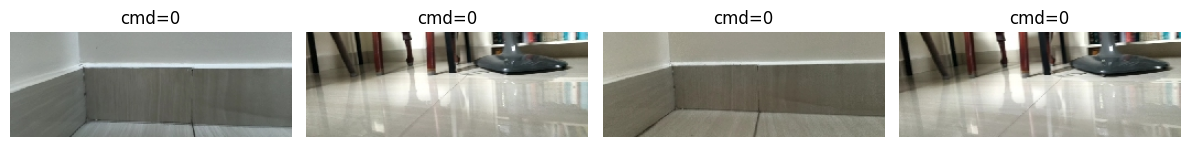

In [23]:
rng = np.random.default_rng(0)
N_PER_CLASS = 4

fig, axes = plt.subplots(len(classes), N_PER_CLASS, figsize=(3 * N_PER_CLASS, 3 * len(classes)))
if len(classes) == 1:
    axes = axes[None, :]

for row_idx, cls in enumerate(classes):
    cls_rows = [r for r in rows if r["cmd"] == cls]
    sample_idx = rng.choice(len(cls_rows), size=min(N_PER_CLASS, len(cls_rows)), replace=False)
    for col_idx, i in enumerate(sample_idx):
        ax = axes[row_idx, col_idx]
        ax.imshow(Image.open(cls_rows[i]["frame"]))
        ax.set_title(f"cmd={cls}")
        ax.axis("off")
    for col_idx in range(len(sample_idx), N_PER_CLASS):
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()
